# COMP663 Assignment 2 — Classical Optimisation

**Student ID:** 1173808  
**Dataset:** `forest_cover_data.csv`  
**Primary metric:** macro-F1  

This notebook improves the supplied neural-network baseline using one classical search method, Bayesian optimisation, and neural architecture search (NAS). Every method uses the same fixed development split and primary metric. Results are produced by running this notebook from a clean kernel.

## Rubric checklist

| Task | Evidence in this notebook |
|---|---|
| 1 | preprocessing, metrics, unchanged baseline, held-out result, candidate ranges |
| 2 | random-search budget, configurations, result table and runtime |
| 3 | Bayesian objective, TPE search space, result table and runtime |
| 4 | random NAS architecture space, result table and runtime |
| 5 | fair held-out comparison, figure, class report, final model |
| 6 | `run.txt` and `predict.py` hidden-test instructions |

In [1]:
from pathlib import Path
import ast
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from sklearn.metrics import balanced_accuracy_score, classification_report, f1_score
from sklearn.model_selection import ParameterSampler, StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn

SEED = 42
DEVICE = torch.device("cpu")
torch.set_num_threads(4)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data" / "forest_cover_data.csv"
FIGURE_PATH = ROOT / "figures" / "performance_comparison.png"
MODEL_PATH = ROOT / "models" / "1173808_Assignment2_final.pt"

DEVELOPMENT_SIZE = 80_000
VALIDATION_SIZE = 20_000
SEARCH_EPOCHS = 20
FINAL_EPOCHS = 100
RANDOM_TRIALS = 6
BAYESIAN_TRIALS = 8
NAS_TRIALS = 8

print(f"torch={torch.__version__}, device={DEVICE}, seed={SEED}")

torch=2.13.0, device=cpu, seed=42


## Task 1 — Baseline model and candidate hyperparameters

### 1.1 Data and preprocessing

Assignment 1 found no missing values and a strong class imbalance. I use the same 14 released features. The ten continuous features are standardised; the four `Wilderness_Area` indicators remain 0/1. The scaler is fitted only on training data, so validation and test data cannot leak into preprocessing. No new feature engineering is used because the supplied features already include terrain, distance, hillshade, and wilderness information.

Macro-F1 is the primary metric because every cover type receives equal weight. Balanced accuracy is secondary because it makes minority-class recall visible. I use a fixed stratified development split for all searches, then a separate 20% stratified held-out test set for the final comparison.

In [2]:
data = pd.read_csv(DATA_PATH)
target = "Cover_Type"
feature_names = [column for column in data.columns if column != target]
continuous_features = [column for column in feature_names if not column.startswith("Wilderness_Area")]

assert data.shape == (571_012, 15), data.shape
assert len(feature_names) == 14
assert set(data[target].unique()) == {1, 2, 3, 4, 5}
assert data.isna().sum().sum() == 0

print("Shape:", data.shape)
print("Features:", feature_names)
display(data[target].value_counts().sort_index().rename("count").to_frame().assign(
    percentage=lambda frame: 100 * frame["count"] / len(data)
))

Shape: (571012, 15)
Features: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4']


,count,percentage
Cover_Type,,
1,209840,36.748790
2,317055,55.525103
3,10240,1.793307
4,15367,2.691187
5,18510,3.241613


In [3]:
train_frame, test_frame = train_test_split(
    data, test_size=0.20, stratify=data[target], random_state=SEED
)

splitter = StratifiedShuffleSplit(n_splits=1, train_size=DEVELOPMENT_SIZE, random_state=SEED)
development_index, _ = next(splitter.split(train_frame, train_frame[target]))
development_frame = train_frame.iloc[development_index].copy()
search_frame, validation_frame = train_test_split(
    development_frame,
    test_size=VALIDATION_SIZE,
    stratify=development_frame[target],
    random_state=SEED,
)

print(f"Training pool: {len(train_frame):,}")
print(f"Search train / validation: {len(search_frame):,} / {len(validation_frame):,}")
print(f"Held-out test: {len(test_frame):,}")

Training pool: 456,809
Search train / validation: 60,000 / 20,000
Held-out test: 114,203


### 1.2 Candidate ranges

| Hyperparameter | Type and range | Expected effect / cost |
|---|---|---|
| Learning rate | log continuous, 0.0003–0.003 | Too high can be unstable; too low learns slowly. |
| Batch size | categorical, 256 / 512 / 1024 | Larger batches reduce updates and may train faster. |
| Weight decay | log continuous, 0–0.001 | Regularises weights; excessive values can underfit. |
| Epochs | integer, 8–12 under the declared budget | More epochs can improve fit but cost more time. |
| Hidden layers, widths, activation | NAS only | Changes model capacity and parameter count. |

The baseline architecture is fixed as required: 14 inputs → 24 Sigmoid units → 12 Sigmoid units → 5 logits. Cross-entropy receives logits directly. Class-weighted loss addresses the imbalance without changing the released training data.

In [4]:
BASELINE_ARCHITECTURE = {"hidden_layers": [24, 12], "activation": "Sigmoid"}
BASELINE_CONFIG = {
    "learning_rate": 1e-3,
    "batch_size": 512,
    "weight_decay": 1e-4,
    "epochs": SEARCH_EPOCHS,
}


class BaselineNN(nn.Module):
    """The architecture supplied in baselineNN.ipynb."""

    def __init__(self, input_size):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 24),
            nn.Sigmoid(),
            nn.Linear(24, 12),
            nn.Sigmoid(),
            nn.Linear(12, 5),
        )

    def forward(self, x):
        return self.layers(x)


class MLP(nn.Module):
    def __init__(self, input_size, hidden_layers, activation):
        super().__init__()
        activation_layer = getattr(nn, activation)
        layers = []
        previous = input_size
        for width in hidden_layers:
            layers.extend([nn.Linear(previous, width), activation_layer()])
            previous = width
        layers.append(nn.Linear(previous, 5))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)


def build_model(architecture):
    if architecture == BASELINE_ARCHITECTURE:
        return BaselineNN(len(feature_names)).to(DEVICE)
    return MLP(len(feature_names), **architecture).to(DEVICE)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())


def prepare_features(train, *others):
    scaler = StandardScaler().fit(train[continuous_features])

    def transform(frame):
        values = frame[feature_names].astype("float32").copy()
        values[continuous_features] = scaler.transform(values[continuous_features])
        return values.to_numpy(dtype=np.float32), frame[target].to_numpy(dtype=np.int64) - 1

    return scaler, [transform(frame) for frame in (train, *others)]


def evaluate(model, x, y):
    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, len(x), 4096):
            batch = torch.tensor(x[start:start + 4096], dtype=torch.float32, device=DEVICE)
            predictions.append(model(batch).argmax(dim=1).cpu().numpy())
    prediction = np.concatenate(predictions)
    return {
        "macro_f1": f1_score(y, prediction, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y, prediction),
        "prediction": prediction,
    }


def train_once(x_train, y_train, x_eval, y_eval, config, architecture):
    epochs = int(config["epochs"])
    batch_size = int(config["batch_size"])
    learning_rate = float(config["learning_rate"])
    weight_decay = float(config["weight_decay"])
    torch.manual_seed(SEED)
    model = build_model(architecture)
    counts = np.bincount(y_train, minlength=5)
    class_weight = len(y_train) / (5 * counts)
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weight, dtype=torch.float32, device=DEVICE))
    optimiser = torch.optim.Adam(
        model.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    x_tensor = torch.tensor(x_train, dtype=torch.float32, device=DEVICE)
    y_tensor = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
    generator = torch.Generator(device=DEVICE).manual_seed(SEED)
    losses = []

    model.train()
    for _ in range(epochs):
        order = torch.randperm(len(x_tensor), generator=generator, device=DEVICE)
        for start in range(0, len(order), batch_size):
            index = order[start:start + batch_size]
            optimiser.zero_grad()
            loss = loss_fn(model(x_tensor[index]), y_tensor[index])
            loss.backward()
            optimiser.step()
            losses.append(loss.item())

    metrics = evaluate(model, x_eval, y_eval)
    metrics["final_loss"] = losses[-1]
    metrics["parameters"] = count_parameters(model)
    return model, metrics


scaler_search, ((x_search, y_search), (x_validation, y_validation)) = prepare_features(
    search_frame, validation_frame
)

In [5]:
baseline_start = time.perf_counter()
_, baseline_validation = train_once(
    x_search, y_search, x_validation, y_validation, BASELINE_CONFIG, BASELINE_ARCHITECTURE
)
baseline_runtime = time.perf_counter() - baseline_start
print({key: round(value, 4) if isinstance(value, float) else value for key, value in baseline_validation.items() if key != "prediction"})
print(f"Baseline validation runtime: {baseline_runtime:.1f} s")

{'macro_f1': 0.4219, 'balanced_accuracy': 0.6962, 'final_loss': 0.8693, 'parameters': 725}
Baseline validation runtime: 2.6 s


## Task 2 — Classical hyperparameter search

The unchanged baseline uses Adam with learning rate 0.001, batch size 512, weight decay 0.0001, and 20 epochs. Its validation score above is used only as a development reference. The final held-out baseline score is reported together with all optimised methods in Task 5; the held-out test is never used to choose a search configuration.

I use **random search** instead of grid search. The learning-rate and weight-decay ranges are more meaningful on a log scale, so a small grid would spend trials on arbitrary combinations. The budget is six trials, each trained for 20 epochs on the same 60,000-row search split and measured on the same 20,000-row validation split. The architecture remains the supplied baseline.

In [6]:
random_space = {
    "learning_rate": [3e-4, 1e-3, 3e-3],
    "batch_size": [256, 512, 1024],
    "weight_decay": [0.0, 1e-5, 1e-4],
}
random_results = []
for trial_number, config in enumerate(ParameterSampler(random_space, n_iter=RANDOM_TRIALS, random_state=SEED), 1):
    config = {**config, "epochs": SEARCH_EPOCHS}
    started = time.perf_counter()
    _, metrics = train_once(x_search, y_search, x_validation, y_validation, config, BASELINE_ARCHITECTURE)
    random_results.append({"trial": trial_number, **config, **{key: metrics[key] for key in ("macro_f1", "balanced_accuracy", "parameters")}, "seconds": time.perf_counter() - started})

random_table = pd.DataFrame(random_results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(random_table.round(4))
best_random = random_table.iloc[0].to_dict()
print("Best random-search configuration:", best_random)
print(f"Total random-search runtime: {random_table['seconds'].sum():.1f} s")

,trial,weight_decay,learning_rate,batch_size,epochs,macro_f1,balanced_accuracy,parameters,seconds
0,1,0.0001,0.0030,256,20,0.4585,0.7436,725,3.0195
1,2,0.0000,0.0010,512,20,0.4228,0.6960,725,3.1731
2,4,0.0000,0.0010,1024,20,0.4043,0.6905,725,0.8933
3,5,0.0000,0.0003,256,20,0.3862,0.6699,725,3.1245
4,3,0.0000,0.0003,512,20,0.3087,0.6218,725,1.4682
5,6,0.0001,0.0003,512,20,0.3085,0.6217,725,1.4648


Best random-search configuration: {'trial': 1.0, 'weight_decay': 0.0001, 'learning_rate': 0.003, 'batch_size': 256.0, 'epochs': 20.0, 'macro_f1': 0.45847184394961565, 'balanced_accuracy': 0.7436346030975031, 'parameters': 725.0, 'seconds': 3.0194584589917213}
Total random-search runtime: 13.1 s


## Task 3 — Bayesian optimisation

The objective is to maximise validation macro-F1 using the unchanged baseline architecture and split. Optuna's TPE sampler models promising and less-promising parameter values from completed trials, then proposes the next configuration from the more promising region. The budget is eight trials of 20 epochs, which is feasible on a normal CPU while still allowing sequential feedback.

In [7]:
bayesian_rows = []


def bayesian_objective(trial):
    config = {
        "learning_rate": trial.suggest_float("learning_rate", 3e-4, 3e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [256, 512, 1024]),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "epochs": SEARCH_EPOCHS,
    }
    started = time.perf_counter()
    _, metrics = train_once(x_search, y_search, x_validation, y_validation, config, BASELINE_ARCHITECTURE)
    bayesian_rows.append({"trial": trial.number + 1, **config, **{key: metrics[key] for key in ("macro_f1", "balanced_accuracy", "parameters")}, "seconds": time.perf_counter() - started})
    return metrics["macro_f1"]


bayesian_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
bayesian_study.optimize(bayesian_objective, n_trials=BAYESIAN_TRIALS)
bayesian_table = pd.DataFrame(bayesian_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(bayesian_table.round(4))
best_bayesian = {**bayesian_study.best_params, "epochs": SEARCH_EPOCHS}
print("Best Bayesian configuration:", best_bayesian)
print(f"Total Bayesian-search runtime: {bayesian_table['seconds'].sum():.1f} s")

,trial,learning_rate,batch_size,weight_decay,epochs,macro_f1,balanced_accuracy,parameters,seconds
0,8,0.0019,1024,0.0000,20,0.4277,0.6974,725,0.9144
1,6,0.0018,1024,0.0000,20,0.4267,0.6967,725,0.9005
2,1,0.0007,256,0.0000,20,0.4242,0.6940,725,2.7958
3,5,0.0012,1024,0.0000,20,0.4154,0.6947,725,1.6879
4,7,0.0012,1024,0.0008,20,0.4067,0.6900,725,0.9393
5,3,0.0003,256,0.0000,20,0.3903,0.6743,725,2.6208
6,4,0.0005,512,0.0000,20,0.3797,0.6692,725,1.4730
7,2,0.0004,512,0.0001,20,0.3723,0.6646,725,1.4780


Best Bayesian configuration: {'learning_rate': 0.0019298279978549665, 'batch_size': 1024, 'weight_decay': 2.091498132903561e-05, 'epochs': 20}
Total Bayesian-search runtime: 12.8 s


## Task 4 — Neural architecture search

This is a fixed-budget **random NAS**. It samples a number of hidden layers, their widths, the activation function, and two training hyperparameters. The search starts from the supplied baseline design but permits only small fully connected alternatives appropriate for tabular data. Eight architectures are trained for the same 20 epochs and evaluated on the same validation split. This makes the NAS comparison computationally feasible and separates architecture choices from the Bayesian training-hyperparameter search.

In [8]:
rng = np.random.default_rng(SEED)
nas_rows = []
for trial_number in range(1, NAS_TRIALS + 1):
    layer_count = int(rng.choice([1, 2, 3]))
    architecture = {
        "hidden_layers": [int(rng.choice([16, 24, 32, 48, 64])) for _ in range(layer_count)],
        "activation": str(rng.choice(["Sigmoid", "ReLU"])),
    }
    config = {
        "learning_rate": float(rng.choice([3e-4, 1e-3, 3e-3])),
        "batch_size": int(rng.choice([256, 512, 1024])),
        "weight_decay": float(rng.choice([0.0, 1e-5, 1e-4])),
        "epochs": SEARCH_EPOCHS,
    }
    started = time.perf_counter()
    _, metrics = train_once(x_search, y_search, x_validation, y_validation, config, architecture)
    nas_rows.append({"trial": trial_number, **config, "hidden_layers": str(architecture["hidden_layers"]), "activation": architecture["activation"], **{key: metrics[key] for key in ("macro_f1", "balanced_accuracy", "parameters")}, "seconds": time.perf_counter() - started})

nas_table = pd.DataFrame(nas_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(nas_table.round(4))
best_nas_row = nas_table.iloc[0].to_dict()
best_nas = {
    "architecture": {"hidden_layers": ast.literal_eval(best_nas_row["hidden_layers"]), "activation": best_nas_row["activation"]},
    "config": {key: best_nas_row[key] for key in ("learning_rate", "batch_size", "weight_decay", "epochs")},
}
print("Best NAS configuration:", best_nas)
print(f"Total NAS runtime: {nas_table['seconds'].sum():.1f} s")

,trial,learning_rate,batch_size,weight_decay,epochs,hidden_layers,activation,macro_f1,balanced_accuracy,parameters,seconds
0,4,0.0030,512,0.0000,20,"[24, 16]",ReLU,0.4914,0.7643,845,1.7666
1,1,0.0010,512,0.0001,20,[48],ReLU,0.4711,0.7518,965,1.1858
2,7,0.0010,1024,0.0001,20,"[48, 24, 16]",ReLU,0.4680,0.7496,2381,1.1032
3,3,0.0003,1024,0.0000,20,"[48, 48, 48]",ReLU,0.4453,0.7288,5669,1.5628
4,6,0.0003,512,0.0000,20,[64],ReLU,0.4451,0.7196,1285,1.3433
5,8,0.0010,256,0.0000,20,"[48, 16, 24]",Sigmoid,0.4258,0.7070,2037,3.2493
6,2,0.0003,512,0.0001,20,[48],Sigmoid,0.3843,0.6576,965,1.2516
7,5,0.0003,512,0.0001,20,"[32, 32, 32]",Sigmoid,0.3749,0.6583,2757,2.2997


Best NAS configuration: {'architecture': {'hidden_layers': [24, 16], 'activation': 'ReLU'}, 'config': {'learning_rate': 0.003, 'batch_size': 512, 'weight_decay': 1e-05, 'epochs': 20}}
Total NAS runtime: 13.8 s


## Task 5 — Performance comparison and final model

For a fair comparison, each selected configuration is retrained on the same 80,000-row development set, with a new scaler fitted on that training data, and then evaluated once on the untouched 20% test set. The search methods differ in their search space and trial budgets; this is reported rather than hidden. The final model is selected from the held-out comparison and then retrained on the complete 80% training pool before saving.

,method,macro_f1,balanced_accuracy,parameters,trials,search_seconds,retrain_seconds
0,Random NAS,0.5121,0.7814,845,8,13.7623,1.7861
1,Random search,0.4705,0.7498,725,6,13.1434,3.4348
2,Bayesian optimisation,0.4260,0.7040,725,8,12.8097,1.0649
3,Baseline,0.4240,0.6951,725,1,2.6253,1.8480


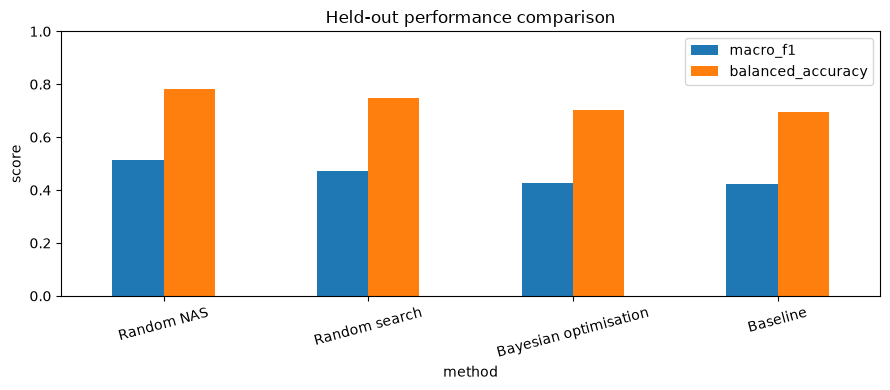

Random NAS has the best held-out macro-F1 (0.5121), an improvement of 0.0881 over the baseline.
Its 845 parameters are 120 more than the baseline, while its search used 8 trials and 13.8 s.
The comparison is fair on preprocessing, seed, development data, held-out test data, and metrics; it is not a controlled comparison of search spaces because NAS also changes architecture.


In [9]:
def evaluate_selected(name, config, architecture, trials, search_seconds):
    scaler, ((x_development, y_development), (x_test, y_test)) = prepare_features(development_frame, test_frame)
    started = time.perf_counter()
    model, metrics = train_once(x_development, y_development, x_test, y_test, config, architecture)
    return {
        "method": name,
        "macro_f1": metrics["macro_f1"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "parameters": metrics["parameters"],
        "trials": trials,
        "search_seconds": search_seconds,
        "retrain_seconds": time.perf_counter() - started,
        "config": config,
        "architecture": architecture,
    }


comparison_rows = [
    evaluate_selected("Baseline", BASELINE_CONFIG, BASELINE_ARCHITECTURE, 1, baseline_runtime),
    evaluate_selected("Random search", {key: best_random[key] for key in ("learning_rate", "batch_size", "weight_decay", "epochs")}, BASELINE_ARCHITECTURE, RANDOM_TRIALS, random_table["seconds"].sum()),
    evaluate_selected("Bayesian optimisation", best_bayesian, BASELINE_ARCHITECTURE, BAYESIAN_TRIALS, bayesian_table["seconds"].sum()),
    evaluate_selected("Random NAS", best_nas["config"], best_nas["architecture"], NAS_TRIALS, nas_table["seconds"].sum()),
]
comparison = pd.DataFrame(comparison_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(comparison.drop(columns=["config", "architecture"]).round(4))

ax = comparison.plot.bar(x="method", y=["macro_f1", "balanced_accuracy"], ylim=(0, 1), figsize=(9, 4), rot=15)
ax.set_ylabel("score")
ax.set_title("Held-out performance comparison")
plt.tight_layout()
plt.savefig(FIGURE_PATH, dpi=150)
plt.show()

winner = comparison.iloc[0]
baseline_row = comparison.loc[comparison["method"] == "Baseline"].iloc[0]
print(
    f"{winner['method']} has the best held-out macro-F1 ({winner['macro_f1']:.4f}), "
    f"an improvement of {winner['macro_f1'] - baseline_row['macro_f1']:.4f} over the baseline."
)
print(
    f"Its {int(winner['parameters'])} parameters are {int(winner['parameters'] - baseline_row['parameters'])} "
    f"more than the baseline, while its search used {int(winner['trials'])} trials and {winner['search_seconds']:.1f} s."
)
print(
    "The comparison is fair on preprocessing, seed, development data, held-out test data, and metrics; "
    "it is not a controlled comparison of search spaces because NAS also changes architecture."
)

In [10]:
selected = comparison.iloc[0]
final_config = selected["config"].copy()
final_config["epochs"] = FINAL_EPOCHS
final_architecture = selected["architecture"]

final_scaler, ((x_full_train, y_full_train), (x_test, y_test)) = prepare_features(train_frame, test_frame)
final_start = time.perf_counter()
final_model, final_metrics = train_once(
    x_full_train, y_full_train, x_test, y_test, final_config, final_architecture
)
final_runtime = time.perf_counter() - final_start
report = pd.DataFrame(classification_report(y_test + 1, final_metrics["prediction"] + 1, output_dict=True)).T

print("Selected method:", selected["method"])
print("Final configuration:", {"architecture": final_architecture, **final_config})
print("Final held-out macro-F1:", round(final_metrics["macro_f1"], 4))
print("Final held-out balanced accuracy:", round(final_metrics["balanced_accuracy"], 4))
print("Final training seconds:", round(final_runtime, 1))
display(report.round(4))

torch.save(
    {
        "state_dict": final_model.state_dict(),
        "architecture": final_architecture,
        "feature_names": feature_names,
        "continuous_features": continuous_features,
        "scaler_mean": final_scaler.mean_.tolist(),
        "scaler_scale": final_scaler.scale_.tolist(),
        "config": final_config,
    },
    MODEL_PATH,
)
assert MODEL_PATH.exists() and MODEL_PATH.stat().st_size > 0
print(f"Saved final model: {MODEL_PATH}")

Selected method: Random NAS
Final configuration: {'architecture': {'hidden_layers': [24, 16], 'activation': 'ReLU'}, 'learning_rate': 0.003, 'batch_size': 512, 'weight_decay': 1e-05, 'epochs': 100}
Final held-out macro-F1: 0.5842
Final held-out balanced accuracy: 0.8381
Final training seconds: 47.9


,precision,recall,f1-score,support
1,0.7192,0.7220,0.7206,41968.00
2,0.8496,0.6326,0.7252,63411.00
3,0.2343,0.9155,0.3732,2048.00
4,0.3354,0.9466,0.4953,3074.00
5,0.4405,0.9735,0.6066,3702.00
accuracy,0.6900,0.6900,0.6900,0.69
macro avg,0.5158,0.8381,0.5842,114203.00
weighted avg,0.7635,0.6900,0.7072,114203.00


Saved final model: /Users/yangliu/Documents/aimaster/1173808-COMP663A2/models/1173808_Assignment2_final.pt


### Interpretation and limitations

The table and figure above are the evidence for the final selection. All methods use the same primary metric, development data, held-out test set, seed, preprocessing rule, and epoch budget during search. The search methods are not identical: Bayesian optimisation uses sequential trial feedback, while NAS also changes architecture. Therefore, performance differences may reflect both search quality and search-space differences.

The model is limited by the released dataset, the fixed compute budget, and one random seed. The rare class remains difficult even with class-weighted loss. The final model uses no external data and should be rerun if hardware, package versions, or the declared budget change.

## Task 6 — Hidden-test prediction

From the repository root, run:

```bash
python predict.py data/hidden_test.csv data/predictions.csv models/1173808_Assignment2_final.pt
```

The hidden CSV must contain the same 14 feature columns. `Cover_Type` is ignored if present. The command writes one `Cover_Type` prediction per row. The saved checkpoint includes the fitted scaler, feature order, model architecture, and state dictionary, so no separate preprocessing program is required.